## Delivery Time Estimator for Olist Marketplace


### **Goal**: Predict the number of days between order placement and delivery to set accurate expectations for customers.

### **Why**: Reducing delivery-related complaints (which account for ~45% of bad reviews) by providing realistic estimates.

### **Approach**:
#### 1. Load and merge relevant datasets
#### 2. Engineer features available at order time (distance, seller history, product category, etc.)
#### 3. Train multiple regression models
#### 4. Compare performance using MAE, RMSE, and business-friendly metrics



# ## 1. Setup and Data Loading


In [1]:
# =========================
# 1. Importing Libraries
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# For distance calculation
from math import radians, sin, cos, sqrt, asin

# For modeling
from sklearn.model_selection import train_test_split, TimeSeriesSplit, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# Load datasets

from pathlib import Path


DATA_DIR = Path("C:/Users/priya/Downloads/olist/data")

print("Loading datasets...")
orders = pd.read_csv(DATA_DIR / 'olist_orders_dataset.csv')
items = pd.read_csv(DATA_DIR / 'olist_order_items_dataset.csv')
products = pd.read_csv(DATA_DIR / 'olist_products_dataset.csv')
sellers = pd.read_csv(DATA_DIR / 'olist_sellers_dataset.csv')
customers = pd.read_csv(DATA_DIR / 'olist_customers_dataset.csv')
geolocation = pd.read_csv(DATA_DIR / 'olist_geolocation_dataset.csv')
payments = pd.read_csv(DATA_DIR / 'olist_order_payments_dataset.csv')
reviews = pd.read_csv(DATA_DIR / 'olist_order_reviews_dataset.csv')
category_translation = pd.read_csv(DATA_DIR / 'product_category_name_translation.csv')
print("Datasets loaded successfully!")

print(f"Orders: {len(orders)}")
print(f"Items: {len(items)}")
print(f"Products: {len(products)}")
print(f"Sellers: {len(sellers)}")
print(f"Customers: {len(customers)}")
print(f"Geolocation: {len(geolocation)}")


Loading datasets...
Datasets loaded successfully!
Orders: 99441
Items: 112650
Products: 32951
Sellers: 3095
Customers: 99441
Geolocation: 1000163


# Basic sanity check

In [3]:

dfs = {
    "orders": orders,
    "items": items,
    "payments": payments,
    "customers": customers,
    "sellers": sellers,
    "products": products,
    "reviews": reviews,
    "geolocation": geolocation,
    "category_translation": category_translation,
}

for name, df in dfs.items():
    print(f"\n{name.upper()}")
    print(df.shape)
    display(df.head())


ORDERS
(99441, 8)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00



ITEMS
(112650, 7)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14



PAYMENTS
(103886, 5)


...

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53



GEOLOCATION
(1000163, 5)


,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP



CATEGORY_TRANSLATION
(71, 2)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


# Making formats consistent

In [4]:
# Convert dates
order_date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_cols:
    orders[col] = pd.to_datetime(orders[col])

items["shipping_limit_date"] = pd.to_datetime(items["shipping_limit_date"])

review_date_cols = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_cols:
    reviews[col] = pd.to_datetime(reviews[col])

# Data Quality

In [5]:
def missing_report(df, name):
    miss = df.isnull().sum()
    pct  = (miss / len(df) * 100).round(1)
    report = pd.DataFrame({'missing_count': miss, 'missing_pct': pct})
    report = report[report['missing_count'] > 0].sort_values('missing_pct', ascending=False)
    print(f'\n── {name} ({df.shape[0]:,} rows) ──')
    print(report.to_string() if not report.empty else '  No missing values ✓')


In [6]:
for name, df in dfs.items():
    missing_report(df, name)


── orders (99,441 rows) ──
                               missing_count  missing_pct
order_delivered_customer_date           2965          3.0
order_delivered_carrier_date            1783          1.8
order_approved_at                        160          0.2

── items (112,650 rows) ──
  No missing values ✓

── payments (103,886 rows) ──
  No missing values ✓

── customers (99,441 rows) ──
  No missing values ✓

── sellers (3,095 rows) ──
  No missing values ✓

── products (32,951 rows) ──
                            missing_count  missing_pct
product_category_name                 610          1.9
product_name_lenght                   610          1.9
product_description_lenght            610          1.9
product_photos_qty                    610          1.9
product_weight_g                        2          0.0
product_length_cm                       2          0.0
product_height_cm                       2          0.0
product_width_cm                        2          0.0

── revie

### 3. Feature Engineering


#### We'll create features that are known at the time of order placement:


In [7]:
# Define target: delivery time in days from purchase to customer delivery
orders['delivery_time_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / (24*3600)


In [8]:
# Compute seller processing time (from approval to carrier delivery)
orders['processing_days'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / (24*3600)

# Compute transit time (from carrier to customer)
orders['transit_days'] = (orders['order_delivered_customer_date'] - orders['order_delivered_carrier_date']).dt.total_seconds() / (24*3600)


In [9]:
# Clip negative or unrealistic values (data quality issues)
orders['processing_days'] = orders['processing_days'].clip(lower=0, upper=30)
orders['transit_days'] = orders['transit_days'].clip(lower=0, upper=60)


In [10]:
# Keep only delivered orders (where delivery_time_days is not null)
delivered_orders = orders[orders['delivery_time_days'].notna()].copy()
print(f"Delivered orders: {len(delivered_orders)}")


Delivered orders: 96476


In [11]:
# Remove outliers (optional: keep 99th percentile)
upper_limit = delivered_orders['delivery_time_days'].quantile(0.99)
delivered_orders = delivered_orders[delivered_orders['delivery_time_days'] <= upper_limit]
print(f"After removing extreme outliers (>99th percentile): {len(delivered_orders)}")


After removing extreme outliers (>99th percentile): 95511


In [12]:
# 3.1 Merge items to get products and sellers per order
order_items = delivered_orders[['order_id', 'order_purchase_timestamp']].merge(
    items[['order_id', 'product_id', 'seller_id', 'price', 'freight_value']], 
    on='order_id', how='left'
)


In [13]:
# 3.2 Merge product info
order_items = order_items.merge(
    products[['product_id', 'product_category_name', 'product_weight_g', 
              'product_length_cm', 'product_height_cm', 'product_width_cm']],
    on='product_id', how='left'
)


In [14]:
# 3.3 Merge seller location
order_items = order_items.merge(
    sellers[['seller_id', 'seller_zip_code_prefix', 'seller_state']], 
    on='seller_id', how='left'
)


In [15]:
# 3.4 Merge customer location (from orders, via customers)
customer_geo = customers[['customer_id', 'customer_zip_code_prefix', 'customer_state']]
orders_with_customer = delivered_orders[['order_id', 'customer_id']].merge(
    customer_geo, on='customer_id', how='left')

order_items = order_items.merge(
    orders_with_customer[['order_id', 'customer_zip_code_prefix', 'customer_state']], on='order_id', how='left')


In [16]:
# 3.5 Add geolocation coordinates for seller and customer zip prefixes
# Use first occurrence of each zip prefix in geolocation (since multiple entries per prefix)
geolocation_unique = geolocation.groupby('geolocation_zip_code_prefix').agg({
    'geolocation_lat': 'mean',
    'geolocation_lng': 'mean'
}).reset_index()
geolocation_unique.columns = ['zip_code_prefix', 'lat', 'lng']



In [17]:
# Merge seller coordinates
order_items = order_items.merge(
    geolocation_unique, 
    left_on='seller_zip_code_prefix', 
    right_on='zip_code_prefix', 
    how='left', 
    suffixes=('', '_seller')
).rename(columns={'lat': 'seller_lat', 'lng': 'seller_lng'}).drop('zip_code_prefix', axis=1)


In [18]:
# Merge customer coordinates
order_items = order_items.merge(
    geolocation_unique, 
    left_on='customer_zip_code_prefix', 
    right_on='zip_code_prefix', 
    how='left', 
    suffixes=('', '_cust')
).rename(columns={'lat': 'cust_lat', 'lng': 'cust_lng'}).drop('zip_code_prefix', axis=1)


In [19]:
print(order_items.columns.tolist())

['order_id', 'order_purchase_timestamp', 'product_id', 'seller_id', 'price', 'freight_value', 'product_category_name', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'seller_zip_code_prefix', 'seller_state', 'customer_zip_code_prefix', 'customer_state', 'seller_lat', 'seller_lng', 'cust_lat', 'cust_lng']


In [20]:
# ### 3.6 Distance Calculation (Haversine)

def haversine(lat1, lon1, lat2, lon2):
    """
    Calculate the great-circle distance between two points
    on the Earth (specified in decimal degrees)
    """
    # Convert decimal degrees to radians
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    # Haversine formula
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a))
    # Radius of earth in kilometers is 6371
    km = 6371 * c
    return km


In [21]:
# Apply only where coordinates exist
order_items['distance_km'] = order_items.apply(
    lambda row: haversine(row['seller_lat'], row['seller_lng'], 
                          row['cust_lat'], row['cust_lng']) 
    if pd.notna(row['seller_lat']) and pd.notna(row['cust_lat']) else np.nan,
    axis=1
)


In [22]:
# ### 3.7 Temporal Features (from order purchase timestamp)

# %%
order_items['purchase_month'] = order_items['order_purchase_timestamp'].dt.month
order_items['purchase_day_of_week'] = order_items['order_purchase_timestamp'].dt.dayofweek  # Monday=0
order_items['purchase_hour'] = order_items['order_purchase_timestamp'].dt.hour
order_items['is_weekend'] = order_items['purchase_day_of_week'].apply(lambda x: 1 if x >= 5 else 0)


In [23]:
# ### 3.8 Product Features

# %%
# Product volume (cm^3) as a proxy for size
order_items['product_volume_cm3'] = (order_items['product_length_cm'] * 
                                      order_items['product_height_cm'] * 
                                      order_items['product_width_cm']).fillna(0)

# Weight in kg
order_items['product_weight_kg'] = order_items['product_weight_g'] / 1000

# Freight value relative to price (shipping cost importance)
order_items['freight_ratio'] = order_items['freight_value'] / (order_items['price'] + 1e-5)


In [24]:
# ### 3.9 Seller Historical Performance
# For each seller, compute average delivery time and standard deviation from past orders (using training data only to avoid leakage). We'll create this feature later after splitting.

# %%
# We'll create a function to add seller stats based on training set.



In [25]:
# ### 3.10 Product Category Encoding
# We'll use the category translation to get English names and then one-hot encode.

# %%
# Merge category translation
order_items = order_items.merge(category_translation, on='product_category_name', how='left')
order_items['product_category_name_english'].fillna('unknown', inplace=True)



0                    housewares
1                     perfumery
2                          auto
3                      pet_shop
4                    stationery
                  ...          
109126                     baby
109127        home_appliances_2
109128    computers_accessories
109129    computers_accessories
109130            health_beauty
Name: product_category_name_english, Length: 109131, dtype: str

In [26]:
# ### 3.11 Aggregate order-level features (FIXED VERSION)

order_features = order_items.groupby('order_id').agg({

    # distance & physical features
    'distance_km': 'mean',
    'product_weight_kg': 'sum',
    'product_volume_cm3': 'sum',

    # economic features
    'price': 'sum',
    'freight_value': 'sum',
    'freight_ratio': 'mean',

    # temporal features
    'purchase_month': 'first',
    'purchase_day_of_week': 'first',
    'purchase_hour': 'first',
    'is_weekend': 'first',

    # category
    'product_category_name_english': lambda x: x.mode()[0] if not x.mode().empty else 'unknown',

    # seller identity
    'seller_id': 'first',

    # ✅ CRITICAL: preserve geo features
    'seller_zip_code_prefix': 'first',
    'customer_zip_code_prefix': 'first',

    # ✅ also preserve states (needed for state features)
    'seller_state': 'first',
    'customer_state': 'first'

    # timestamps needed for tenure and rolling features
    # 'first_order_purchase_timestamp': 'first'

}).reset_index()



In [27]:
# Merge back the target variables (delivery_time_days, processing_days, transit_days) from delivered_orders
order_features = order_features.merge(
    delivered_orders[['order_id', 'delivery_time_days', 'processing_days', 'transit_days']], 
    on='order_id', 
    how='inner'
)


print(f"Final feature set: {order_features.shape}")


Final feature set: (95511, 20)


### 4. Train/Test Split (Time-Based)


#### Since we are predicting future deliveries, we should split by time.


In [28]:
# Get the purchase timestamp for each order from original orders
order_time = orders[['order_id', 'order_purchase_timestamp']].drop_duplicates()
order_features = order_features.merge(order_time, on='order_id', how='left')

# Sort by time
order_features = order_features.sort_values('order_purchase_timestamp')


In [29]:
# Use first 80% for training, last 20% for testing
split_idx = int(len(order_features) * 0.8)
train_df = order_features.iloc[:split_idx].copy()
test_df = order_features.iloc[split_idx:].copy()

print(f"Train period: {train_df['order_purchase_timestamp'].min()} to {train_df['order_purchase_timestamp'].max()}")
print(f"Test period: {test_df['order_purchase_timestamp'].min()} to {test_df['order_purchase_timestamp'].max()}")
print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")


Train period: 2016-10-03 09:44:50 to 2018-05-28 10:04:33
Test period: 2018-05-28 10:14:08 to 2018-08-29 15:00:37
Train size: 76408, Test size: 19103


### 5. Advanced Feature Engineering (using training data only)


In [30]:
# 5.1 Global averages (for filling missing)
global_avg_delivery = train_df['delivery_time_days'].mean()
global_avg_processing = train_df['processing_days'].mean()
global_avg_transit = train_df['transit_days'].mean()

# 5.2 Seller historical stats (processing, transit, total)
seller_processing_stats = train_df.groupby('seller_id')['processing_days'].agg(['mean', 'std']).reset_index()
seller_processing_stats.columns = ['seller_id', 'seller_avg_processing', 'seller_std_processing']

seller_transit_stats = train_df.groupby('seller_id')['transit_days'].agg(['mean', 'std']).reset_index()
seller_transit_stats.columns = ['seller_id', 'seller_avg_transit', 'seller_std_transit']

seller_total_stats = train_df.groupby('seller_id')['delivery_time_days'].agg(['mean', 'std']).reset_index()
seller_total_stats.columns = ['seller_id', 'seller_avg_delivery', 'seller_std_delivery']

# Merge into train and test
train_df = train_df.merge(seller_processing_stats, on='seller_id', how='left')
train_df = train_df.merge(seller_transit_stats, on='seller_id', how='left')
train_df = train_df.merge(seller_total_stats, on='seller_id', how='left')

test_df = test_df.merge(seller_processing_stats, on='seller_id', how='left')
test_df = test_df.merge(seller_transit_stats, on='seller_id', how='left')
test_df = test_df.merge(seller_total_stats, on='seller_id', how='left')

# Fill missing for new sellers in test set
for df in [train_df, test_df]:
    df['seller_avg_processing'].fillna(global_avg_processing, inplace=True)
    df['seller_std_processing'].fillna(0, inplace=True)
    df['seller_avg_transit'].fillna(global_avg_transit, inplace=True)
    df['seller_std_transit'].fillna(0, inplace=True)
    df['seller_avg_delivery'].fillna(global_avg_delivery, inplace=True)
    df['seller_std_delivery'].fillna(0, inplace=True)


In [31]:
# 5.3 Category-level processing average
cat_processing_avg = train_df.groupby('product_category_name_english')['processing_days'].mean().reset_index()
cat_processing_avg.columns = ['product_category_name_english', 'cat_avg_processing']
train_df = train_df.merge(cat_processing_avg, on='product_category_name_english', how='left')
test_df = test_df.merge(cat_processing_avg, on='product_category_name_english', how='left')

train_df['cat_avg_processing'].fillna(global_avg_processing, inplace=True)
test_df['cat_avg_processing'].fillna(global_avg_processing, inplace=True)


0        2.513407
1        2.881784
2        2.123985
3        2.433017
4        3.174631
           ...   
19098    2.513407
19099    3.368084
19100    2.659902
19101    1.833825
19102    3.174631
Name: cat_avg_processing, Length: 19103, dtype: float64

In [32]:
# === NEW FEATURES: seller volume, route performance, and log target ===

# Seller total orders (experience proxy)
seller_order_counts = (
    train_df.groupby('seller_id')
    .size()
    .reset_index(name='seller_total_orders')
)

train_df = train_df.merge(seller_order_counts, on='seller_id', how='left')

# IMPORTANT: avoid duplicate column issue
test_df = test_df.merge(
    seller_order_counts,
    on='seller_id',
    how='left',
    suffixes=('', '_dup')
)

# Seller tenure (days since first order)

seller_first_order = (
    train_df.groupby('seller_id')['order_purchase_timestamp']
    .min()
    .reset_index()
)

seller_first_order = seller_first_order.rename(
    columns={'order_purchase_timestamp': 'seller_first_order_date'}
)

# Remove column if already exists to avoid suffix issues
if 'seller_first_order_date' in train_df.columns:
    train_df = train_df.drop(columns=['seller_first_order_date'])

if 'seller_first_order_date' in test_df.columns:
    test_df = test_df.drop(columns=['seller_first_order_date'])


# Now merge safely
train_df = train_df.merge(
    seller_first_order,
    on='seller_id',
    how='left'
)

test_df = test_df.merge(
    seller_first_order,
    on='seller_id',
    how='left'
)


# Now compute tenure safely
train_df['seller_tenure_days'] = (
    train_df['order_purchase_timestamp']
    - train_df['seller_first_order_date']
).dt.days

test_df['seller_tenure_days'] = (
    test_df['order_purchase_timestamp']
    - test_df['seller_first_order_date']
).dt.days

print("Seller tenure feature created successfully")


# Route feature
train_df['route'] = (
    train_df['seller_zip_code_prefix'].astype(str)
    + '_'
    + train_df['customer_zip_code_prefix'].astype(str)
)

test_df['route'] = (
    test_df['seller_zip_code_prefix'].astype(str)
    + '_'
    + test_df['customer_zip_code_prefix'].astype(str)
)

route_stats = (
    train_df.groupby('route')['delivery_time_days']
    .agg(['mean','std'])
    .reset_index()
    .rename(columns={
        'mean': 'route_avg_delivery',
        'std': 'route_std_delivery'
    })
)

train_df = train_df.merge(route_stats, on='route', how='left')
test_df = test_df.merge(route_stats, on='route', how='left')


# Log target (train only needed, test optional)
train_df['delivery_time_log'] = np.log1p(train_df['delivery_time_days'])

if 'delivery_time_days' in test_df.columns:
    test_df['delivery_time_log'] = np.log1p(test_df['delivery_time_days'])


print("Feature engineering completed successfully")

Seller tenure feature created successfully
Feature engineering completed successfully


In [33]:

# === NEW: Rolling seller historical features (NO LEAKAGE) ===

train_df = train_df.sort_values('order_purchase_timestamp')
test_df = test_df.sort_values('order_purchase_timestamp')

# rolling mean delivery per seller (last 50 orders)
train_df['seller_roll_avg_delivery'] = (
    train_df.groupby('seller_id')['delivery_time_days']
    .transform(lambda x: x.shift(1).rolling(50, min_periods=5).mean())
)

train_df['seller_roll_std_delivery'] = (
    train_df.groupby('seller_id')['delivery_time_days']
    .transform(lambda x: x.shift(1).rolling(50, min_periods=5).std())
)

# apply global fallback
global_delivery_mean = train_df['delivery_time_days'].mean()
train_df['seller_roll_avg_delivery'] = train_df['seller_roll_avg_delivery'].fillna(global_delivery_mean)
train_df['seller_roll_std_delivery'] = train_df['seller_roll_std_delivery'].fillna(train_df['seller_roll_std_delivery'].median())

# merge into test using seller averages from train
seller_roll_stats = train_df.groupby('seller_id')[['seller_roll_avg_delivery','seller_roll_std_delivery']].last().reset_index()
test_df = test_df.merge(seller_roll_stats, on='seller_id', how='left')

test_df['seller_roll_avg_delivery'] = test_df['seller_roll_avg_delivery'].fillna(global_delivery_mean)
test_df['seller_roll_std_delivery'] = test_df['seller_roll_std_delivery'].fillna(train_df['seller_roll_std_delivery'].median())

print("Added rolling seller delivery features")


Added rolling seller delivery features


In [34]:

# === NEW: State pair features ===

train_df['state_pair'] = train_df['seller_state'] + "_" + train_df['customer_state']
test_df['state_pair'] = test_df['seller_state'] + "_" + test_df['customer_state']

state_stats = train_df.groupby('state_pair')['delivery_time_days'].agg(['mean','std']).reset_index()
state_stats.columns = ['state_pair','state_pair_avg_delivery','state_pair_std_delivery']

train_df = train_df.merge(state_stats, on='state_pair', how='left')
test_df = test_df.merge(state_stats, on='state_pair', how='left')

print("Added state pair features")


Added state pair features


In [35]:

# === NEW: Order complexity features ===

order_complexity = train_df.groupby('order_id').size().reset_index(name='num_items_in_order')
train_df = train_df.merge(order_complexity, on='order_id', how='left')
test_df = test_df.merge(order_complexity, on='order_id', how='left')

train_df['num_items_in_order'] = train_df['num_items_in_order'].fillna(1)
test_df['num_items_in_order'] = test_df['num_items_in_order'].fillna(1)

print("Added order complexity features")


Added order complexity features


In [36]:
# 5.4 Category-level transit average (optional)
cat_transit_avg = train_df.groupby('product_category_name_english')['transit_days'].mean().reset_index()
cat_transit_avg.columns = ['product_category_name_english', 'cat_avg_transit']
train_df = train_df.merge(cat_transit_avg, on='product_category_name_english', how='left')
test_df = test_df.merge(cat_transit_avg, on='product_category_name_english', how='left')
train_df['cat_avg_transit'].fillna(global_avg_transit, inplace=True)
test_df['cat_avg_transit'].fillna(global_avg_transit, inplace=True)


0         8.909668
1        10.202200
2         9.425018
3         9.746930
4         9.853094
           ...    
19098     8.909668
19099     9.604670
19100     9.469640
19101     8.956854
19102     9.853094
Name: cat_avg_transit, Length: 19103, dtype: float64

In [37]:
# 5.5 Distance bins (optional, but we'll keep as numeric for now)
train_df['distance_km'].fillna(train_df['distance_km'].median(), inplace=True)
test_df['distance_km'].fillna(train_df['distance_km'].median(), inplace=True)


0        736.420673
1        300.376749
2        552.961505
3        851.923745
4        497.901698
            ...    
19098     19.570667
19099      9.722594
19100    430.333354
19101     10.326728
19102    141.512819
Name: distance_km, Length: 19103, dtype: float64

### 6. Prepare Feature Matrix


In [51]:
# Define feature columns (available at order time)
numeric_features = [
    'distance_km', 'product_weight_kg', 'product_volume_cm3', 'price', 'freight_value',
    'freight_ratio', 'purchase_hour',
    'seller_avg_delivery', 'seller_std_delivery',
    'seller_avg_processing', 'seller_std_processing',
    'seller_avg_transit', 'seller_std_transit',
    'cat_avg_processing', 'cat_avg_transit'
,
    'seller_total_orders', 'seller_tenure_days',
    'route_avg_delivery', 'route_std_delivery'
,
    'seller_roll_avg_delivery', 'seller_roll_std_delivery',
    'state_pair_avg_delivery', 'state_pair_std_delivery',
    'num_items_in_order'
]

categorical_features = [
    'purchase_month', 'purchase_day_of_week', 'is_weekend', 'product_category_name_english'
,
    'seller_total_orders', 'seller_tenure_days',
    'route_avg_delivery', 'route_std_delivery'
,
    'seller_roll_avg_delivery', 'seller_roll_std_delivery',
    'state_pair_avg_delivery', 'state_pair_std_delivery',
    'num_items_in_order'
]


In [52]:
# For simplicity, we'll drop rows with missing target (none) and ensure no NaNs in features
train_df = train_df.dropna(subset=numeric_features + categorical_features)
test_df = test_df.dropna(subset=numeric_features + categorical_features)


In [53]:
X_train = train_df[numeric_features + categorical_features]
y_train = train_df['delivery_time_log']
X_test = test_df[numeric_features + categorical_features]
y_test = test_df['delivery_time_log']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")


X_train shape: (7317, 37)
X_test shape: (322, 37)


### 7. Preprocessing Pipelines


In [54]:
# Numeric pipeline: impute median and scale
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute missing with 'missing' and one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ])


In [55]:
# Remove duplicate columns safely
train_df = train_df.loc[:, ~train_df.columns.duplicated()].copy()
test_df  = test_df.loc[:, ~test_df.columns.duplicated()].copy()

print("Duplicates removed.")

Duplicates removed.


In [56]:
assert train_df.columns.is_unique
assert test_df.columns.is_unique

print("All columns unique now.")

All columns unique now.


In [57]:
# find duplicate columns
dup_cols = train_df.columns[train_df.columns.duplicated()]
print("Duplicate columns:", dup_cols.tolist())

Duplicate columns: []


### 8. Model Training and Comparison


#### We'll train several models and compare their performance.


In [65]:
print("Duplicate columns in X_train:", X_train.columns[X_train.columns.duplicated()].tolist())

Duplicate columns in X_train: ['seller_total_orders', 'seller_tenure_days', 'route_avg_delivery', 'route_std_delivery', 'seller_roll_avg_delivery', 'seller_roll_std_delivery', 'state_pair_avg_delivery', 'state_pair_std_delivery', 'num_items_in_order']


In [66]:
X_train = X_train.loc[:, ~X_train.columns.duplicated()].copy()
X_test  = X_test.loc[:, ~X_test.columns.duplicated()].copy()

In [62]:
# Remove duplicates in source dataframes first
train_df = train_df.loc[:, ~train_df.columns.duplicated()].copy()
test_df  = test_df.loc[:, ~test_df.columns.duplicated()].copy()

# Remove duplicates in feature lists
numeric_features = list(dict.fromkeys(numeric_features))
categorical_features = list(dict.fromkeys(categorical_features))

# Now recreate X_train and X_test
X_train = train_df[numeric_features + categorical_features].copy()
X_test  = test_df[numeric_features + categorical_features].copy()

In [67]:
assert X_train.columns.is_unique, "X_train still has duplicate columns"
assert len(X_train.columns) == len(set(X_train.columns)), "Feature list contains duplicates"

In [58]:
# Define models to compare
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, verbosity=0)
}


In [ ]:
# Store results
results = []

for name, model in models.items():
    # Create pipeline
    pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', model)])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Predict
    y_pred = pipeline.predict(X_test)
    
    # Evaluate
    # mae = mean_absolute_error(y_test, y_pred)
    # rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    # r2 = r2_score(y_test, y_pred)

    y_pred_days = np.expm1(y_pred)
    y_test_days = np.expm1(y_test)

    mae = mean_absolute_error(y_test_days, y_pred_days)
    rmse = np.sqrt(mean_squared_error(y_test_days, y_pred_days))
    r2 = r2_score(y_test_days, y_pred_days)

    within_2_days = np.mean(np.abs(y_test_days - y_pred_days) <= 2) * 100
    
    # Business metric: percentage of predictions within 2 days
    # within_2_days = np.mean(np.abs(y_test - y_pred) <= 2) * 100
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2,
        'Within 2 days (%)': within_2_days
    })
    
    print(f"{name} - MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.3f}, Within 2d: {within_2_days:.1f}%")


Linear Regression - MAE: 6.55, RMSE: 9.52, R2: -4.685, Within 2d: 31.7%
Ridge Regression - MAE: 4.90, RMSE: 6.63, R2: -1.754, Within 2d: 28.3%
Lasso Regression - MAE: 4.99, RMSE: 7.16, R2: -2.210, Within 2d: 30.4%
Decision Tree - MAE: 5.93, RMSE: 8.02, R2: -3.036, Within 2d: 21.4%
Random Forest - MAE: 5.27, RMSE: 6.80, R2: -1.902, Within 2d: 25.2%


### 9. Model Comparison Table


In [ ]:
results_df = pd.DataFrame(results).sort_values('MAE')
print("\n=== Model Performance Comparison ===")
print(results_df.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = ['MAE', 'RMSE', 'Within 2 days (%)']
for i, metric in enumerate(metrics):
    results_df.sort_values(metric, ascending=(metric!='Within 2 days (%)')).plot(
        x='Model', y=metric, kind='bar', ax=axes[i], legend=False, color='skyblue'
    )
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# %% [markdown]
# ## 10. Feature Importance (from best tree-based model)

# %%
# Identify best model by MAE (usually Random Forest or XGBoost)
best_model_name = results_df.loc[results_df['MAE'].idxmin(), 'Model']
print(f"Best model: {best_model_name}")



NameError: name 'results' is not defined

In [ ]:
# Get feature names after preprocessing
preprocessor.fit(X_train)
feature_names = (numeric_features + 
                 list(preprocessor.named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)))



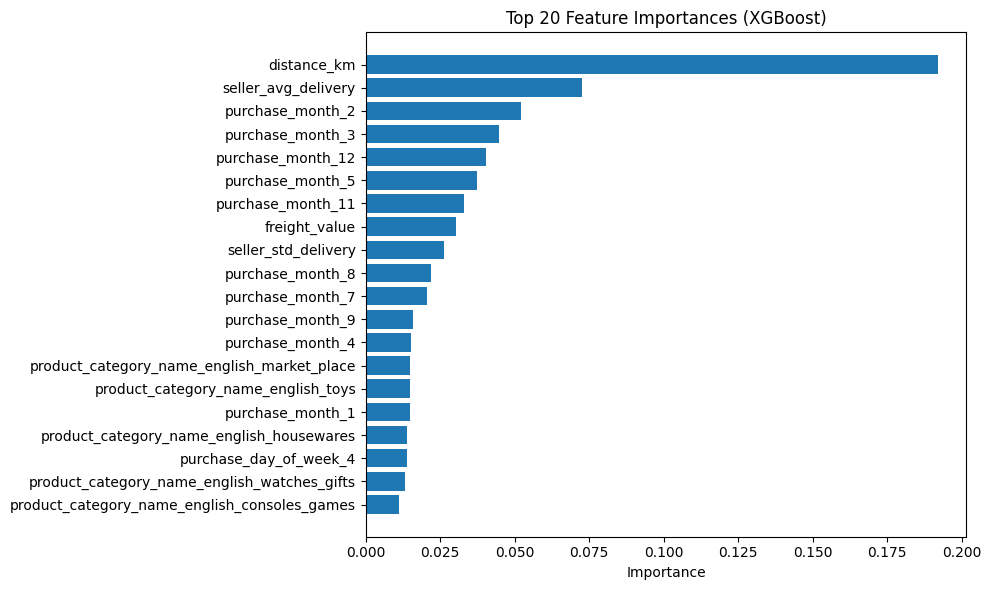

In [ ]:
# For Random Forest or XGBoost, we can extract importance
if best_model_name in ['Random Forest', 'XGBoost', 'Gradient Boosting']:
    # Re-train the best model to get feature importance (if not already)
    best_model = models[best_model_name]
    pipeline_best = Pipeline(steps=[('preprocessor', preprocessor),
                                    ('regressor', best_model)])
    pipeline_best.fit(X_train, y_train)
    
    importances = pipeline_best.named_steps['regressor'].feature_importances_
    feat_imp = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.barh(feat_imp.head(20)['feature'], feat_imp.head(20)['importance'])
    plt.xlabel('Importance')
    plt.title(f'Top 20 Feature Importances ({best_model_name})')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
else:
    print("Best model is linear; feature importance not directly available.")


### 11. Residual Analysis


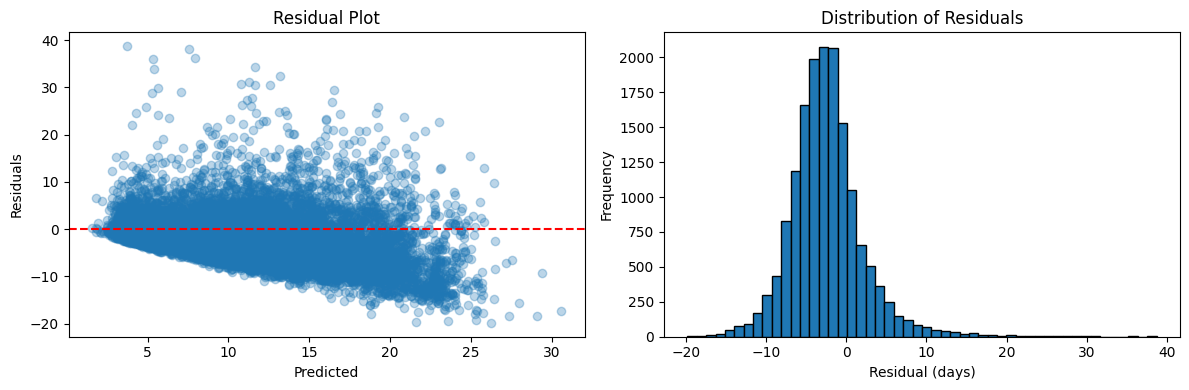

In [ ]:
# Use best model to get predictions on test set
best_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', models[best_model_name])])
best_pipeline.fit(X_train, y_train)
y_pred_best = best_pipeline.predict(X_test)

residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(y_pred_best, residuals, alpha=0.3)
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Residuals')
axes[0].set_title('Residual Plot')

axes[1].hist(residuals, bins=50, edgecolor='black')
axes[1].set_xlabel('Residual (days)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Distribution of Residuals')
plt.tight_layout()
plt.show()


In [ ]:

# === NEW: Convert predictions back to days ===

y_pred_days = np.expm1(y_pred)
y_test_days = np.expm1(y_test)

mae_days = mean_absolute_error(y_test_days, y_pred_days)
rmse_days = np.sqrt(mean_squared_error(y_test_days, y_pred_days))

print(f"MAE (days): {mae_days:.3f}")
print(f"RMSE (days): {rmse_days:.3f}")
